# Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso anual`
- `visitas_mes`
- `compras_mes`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` es de tipo float64 y se presenta de tipo decimal, se procede hacer el respectivo cambio a tipo int

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de datos
df["edad"] = df["edad"].astype(int)

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df[["edad","nivel_ingreso","gasto_publicidad_dirigida","satisfaccion","ingreso_anual","visitas_mes","compras_mes"]].describe()

,edad,nivel_ingreso,gasto_publicidad_dirigida,satisfaccion,ingreso_anual,visitas_mes,compras_mes
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,20.149301,3.603693,36.594180,10.029000,1.206467
std,11.492378,9833.166305,10.880724,0.685300,34.484888,3.158189,1.105284
min,18.000000,8000.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,12.310000,3.100000,0.000000,8.000000,0.000000
50%,38.000000,30023.745000,19.730000,3.600000,30.705000,10.000000,1.000000
75%,46.000000,36768.440000,27.292500,4.100000,58.220000,12.000000,2.000000
max,75.000000,74790.840000,75.510000,5.000000,244.690000,25.000000,8.000000


✍️ **Comentario**:

Diagnóstico inicial de variables numéricas

- `Edad`: La edad promedio de los clientes es de 38.26 años, con una mediana de 38 años, lo que indica una distribución aproximadamente simétrica.
- `Nivel de ingreso`: El ingreso promedio es de 30 019.70, muy cercano a la mediana (30 023.75), lo que sugiere una distribución relativamente equilibrada.
- `Gasto en publicidad dirigida`: El gasto promedio es de 20.15, con una mediana de 19.73, indicando una distribución cercana a la simetría.
- `Satisfacción`: La satisfacción presenta un promedio de 3.60 sobre una escala de 1 a 5, con una mediana de 3.60.
- `Ingreso anual`: El ingreso anual presenta un promedio de 36.59, superior a la mediana (30.71), lo que sugiere una distribución asimétrica hacia la derecha.
- `Visitas al mes`: Los clientes realizan en promedio 10.03 visitas mensuales, con una mediana de 10 visitas.
- `Compras al mes`: El promedio es de 1.21 compras mensuales, mientras que la mediana es de 1 compra, indicando que la mayoría de los clientes realiza pocas compras cada mes.


#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
df[["miembro_premium","abandono"]].nunique()

miembro_premium    2
abandono           2
dtype: int64

In [ ]:
df[["miembro_premium","abandono"]].head(10)

,miembro_premium,abandono
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,1,0
7,0,0
8,1,0
9,0,0


✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` Se identifica que esta variable es de tipo binario por sus dos estados que son 1 y 0
- `abandono` Se identifica que esta variable es de tipo binario por sus dos estados que son 1 y 0  

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
df[["tipo_dispositivo","region"]].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
columnas = ["tipo_dispositivo","region"]

for columna in columnas:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts())


Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


In [ ]:
df["tipo_dispositivo"].value_counts(normalize=True)

móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

In [ ]:
df["region"].value_counts(normalize=True)

norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64

✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo`:
   - La categoría móvil es la más representativa, con 9.818 registros (aproximadamente 65.5 % del total), lo que indica que la mayoría de los clientes interactúa con la plataforma desde dispositivos móviles.
   - La categoría escritorio cuenta con 3 720 registros (24.8 %), siendo el segundo dispositivo más utilizado.
   - La categoría tablet presenta 1 462 registros (9.7 %), por lo que es el dispositivo menos frecuente.
     
- `region`:
   - La distribución por región es relativamente equilibrada, aunque norte concentra la mayor cantidad de clientes con 4 395 registros (29.3 %). Le siguen las regiones oeste con 3 810 registros (25.4 %) y sur con 3 726 registros (24.8 %).
   - La región este presenta la menor participación con 3 069 registros (20.5 %).
   - No se observan diferencias extremadamente marcadas entre las regiones, lo que sugiere una representación adecuada de clientes en todas las zonas geográficas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

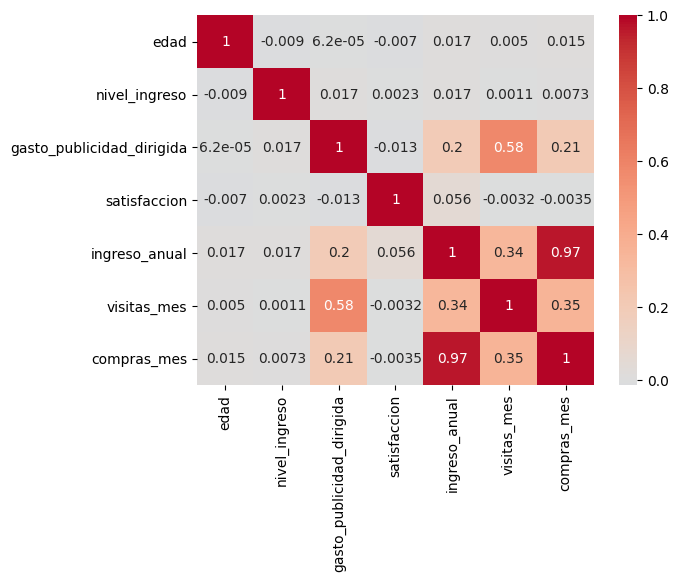

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[["edad","nivel_ingreso","gasto_publicidad_dirigida","satisfaccion","ingreso_anual","visitas_mes","compras_mes"]].corr()
sns.heatmap(corr, annot = True, cmap = "coolwarm", center = 0)
plt.show()

✍️ **Comentario**:

Observaciones generales (Heatmap)  
- Se observa que la mayoría de las variables presentan correlaciones bajas o muy cercanas a cero, indicando una relación lineal débil entre ellas.
- La correlación más alta se encuentra entre ingreso_anual y compras_mes (r = 0.97), lo que evidencia una relación positiva muy fuerte: a mayor ingreso anual, mayor número de compras mensuales.
- También se observa una correlación positiva moderada entre gasto_publicidad_dirigida y visitas_mes (r = 0.58), sugiriendo que un mayor gasto en publicidad se asocia con un mayor número de visitas.
- Las variables edad, nivel_ingreso y satisfaccion presentan correlaciones muy bajas con el resto de variables, por lo que no muestran relaciones lineales importantes.
- No se observan correlaciones negativas de magnitud considerable; las pocas correlaciones negativas presentes son muy cercanas a cero.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva muy fuerte con compras_mes (r = 0.97), indicando que los clientes con mayores ingresos anuales tienden a realizar más compras mensuales.
- Mantiene una correlación positiva moderada con visitas_mes (r = 0.34), lo que sugiere que un mayor ingreso anual está asociado con una mayor frecuencia de visitas.
- Presenta una correlación positiva baja con gasto_publicidad_dirigida (r = 0.20), indicando una asociación lineal débil entre ambas variables.
- Las correlaciones con edad, nivel_ingreso y satisfaccion son muy bajas (cercanas a cero), por lo que no existe una relación lineal significativa con estas variables.


### Scatterplot general

Con el Heatmap evidencie patrones en las columnas que son:
- gasto_publicidad_dirigida - visitas_mes = 0.58
- ingreso_anual - visitas_mes = 0.34
- ingreso_anual - compras_mes = 0.97
- visitas_mes - compras_mes = 0.35

Con el heatmap sabemos que todas las correlaciones son positivas, pero quiero identificar con el Scatterplot por pares de columnas la exixtencia de outliers y el nivel de dispersion de los datos

### Scatterplot para pares clave

Text(0.5, 1.0, 'Grafico de dispersion: Gasto publicitario derigida vs Visitas_mes')

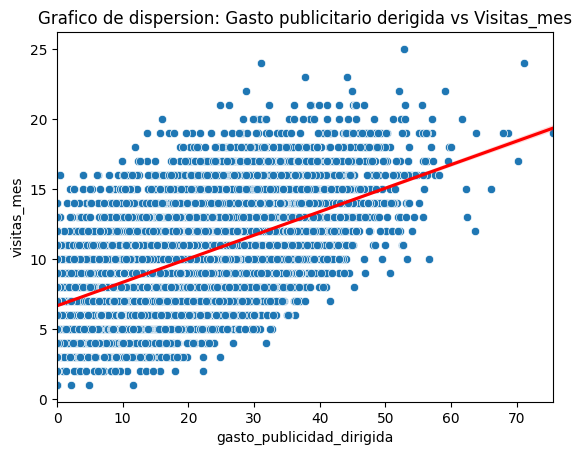

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
#Scatterplot
sns.scatterplot(data = df , x = "gasto_publicidad_dirigida",y = "visitas_mes")
#Linea de tendencia
sns.regplot(data = df , x = "gasto_publicidad_dirigida", y = "visitas_mes", scatter = False , color = 'red')
plt.title("Grafico de dispersion: Gasto publicitario derigida vs Visitas_mes")


Text(0.5, 1.0, 'Grafico de dispersion: Ingreso_anual vs Visitas_mes')

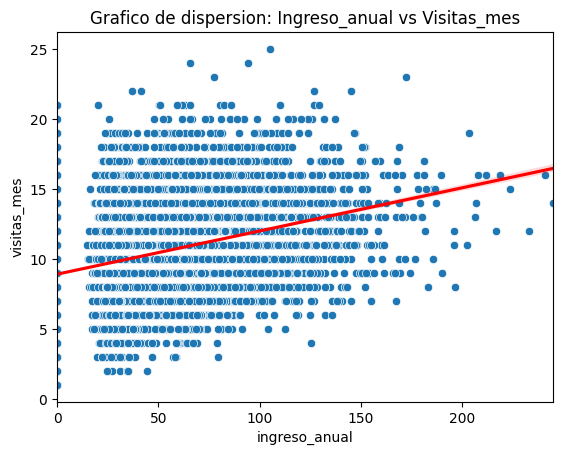

In [ ]:
#Scatterplot
sns.scatterplot(data = df , x = "ingreso_anual",y = "visitas_mes")
#Linea de tendencia
sns.regplot(data = df , x = "ingreso_anual", y = "visitas_mes", scatter = False , color = 'red')
plt.title("Grafico de dispersion: Ingreso_anual vs Visitas_mes")

Text(0.5, 1.0, 'Grafico de dispersion: Ingreso_anual vs Compras_mes')

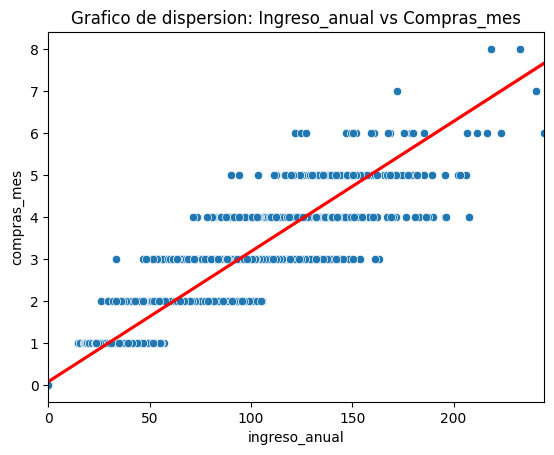

In [ ]:
#Scatterplot
sns.scatterplot(data = df , x = "ingreso_anual",y = "compras_mes")
#Linea de tendencia
sns.regplot(data = df , x = "ingreso_anual", y = "compras_mes", scatter = False , color = 'red')
plt.title("Grafico de dispersion: Ingreso_anual vs Compras_mes")

Text(0.5, 1.0, 'Grafico de dispersion: Visitas_mes vs Compras_mes')

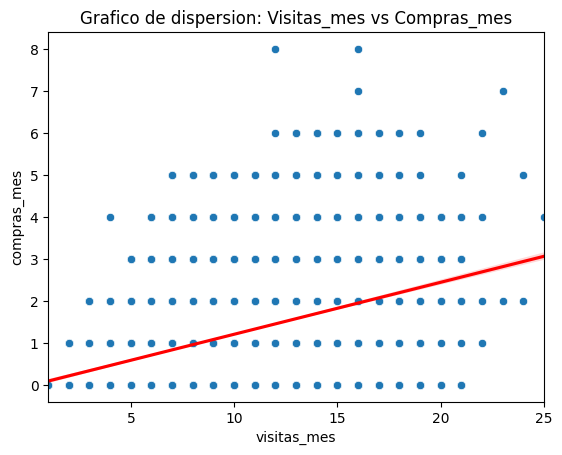

In [ ]:
#Scatterplot
sns.scatterplot(data = df , x = "visitas_mes",y = "compras_mes")
#Linea de tendencia
sns.regplot(data = df , x = "visitas_mes", y = "compras_mes", scatter = False , color = 'red')
plt.title("Grafico de dispersion: Visitas_mes vs Compras_mes")

✍️ **Comentario**:

Observaciones iniciales (Scatterplot)

**Observaciones: Gasto en publicidad dirigida vs Visitas al mes**
- Se observa una relación positiva de magnitud moderada, ya que a medida que aumenta el gasto en publicidad dirigida, también tiende a aumentar el número de visitas al mes. Esta tendencia se evidencia por la pendiente ascendente de la línea de regresión.
- La dispersión es media, debido a que, aunque los datos siguen una tendencia creciente, los puntos presentan una variabilidad considerable alrededor de la línea de regresión.
- No se observan outliers extremos. Existen algunas observaciones con valores altos de gasto publicitario y visitas, pero estas siguen el patrón general de la distribución y no parecen alterar significativamente la tendencia.

**Observaciones: Ingreso anual vs Visitas por mes**
- Se observa que la línea de regresión tiene una pendiente positiva, a mayor ingreso anual, tambien tiende a aumentar visitas por mes. una relacion que muestra la realidad del negocio porque sin visitas no tendriamos ingresos son variables que van relacionadas.
- La dispersión es alta. Los puntos están muy distribuidos verticalmente en casi todos los rangos de ingreso, lo que sugiere que el ingreso anual explica muy poco de la variabilidad en las visitas mensuales. La correlación probablemente es baja (estimada entre r ≈ 0.2 y 0.4).
- Sí hay outliers visibles, principalmente: Un punto aislado cerca de (100, 25) — visitas muy altas para un ingreso medio
Algunos puntos con ingresos altos (>175) y visitas extremas (>20) que se alejan de la tendencia central

**Observaciones: Ingreso anual vs Compras por mes**
- Se observa una relacion positiva pronunciada, indicando una relación fuertemente directa: a mayor ingreso anual, claramente hay más compras por mes.
- La dispersión es baja a media. Los puntos siguen de cerca la línea de regresión, agrupándose en bandas horizontales bien definidas (los valores de compras son discretos: 0, 1, 2, 3...). Esto sugiere una correlación fuerte, estimada en r ≈ 0.97.
- Hay pocos outliers y poco pronunciados

**Observaciones: Visitas por mes vs Compras por mes**
- Se observa una línea de regresión positiva muy leve, lo que indica una relación directa pero extremadamente débil: más visitas no se traducen de forma consistente en más compras.
- La dispersión es muy alta. Los puntos forman una nube casi rectangular y uniforme, sin seguir ningún patrón claro alrededor de la línea. Esto sugiere una correlación muy baja.
- Hay algunos outliers visibles: Puntos en (12, 8) y (16, 8) con compras muy altas para un nivel de visitas medio (16, 7) sigue el mismo patron, los valores extremos de compras_mes (≥6) aparecen dispersos sin relación con las visitas

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
columnas = {"visitas_mes" , "compras_mes","gasto_publicidad_dirigida", "ingreso_anual"}
def corr_numerica(df, columnas, metodo="pearson"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")
corr_numerica(df, columnas, metodo="pearson")


,gasto_publicidad_dirigida,ingreso_anual,visitas_mes,compras_mes
gasto_publicidad_dirigida,1.000000,0.197483,0.578947,0.207528
ingreso_anual,0.197483,1.000000,0.337147,0.967149
visitas_mes,0.578947,0.337147,1.000000,0.353844
compras_mes,0.207528,0.967149,0.353844,1.000000


In [ ]:
# Calcular correlación entre variables relevantes
columnas = {"visitas_mes" , "compras_mes","gasto_publicidad_dirigida", "ingreso_anual"}
def corr_numerica(df, columnas, metodo="spearman"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")
corr_numerica(df, columnas, metodo="spearman")


,gasto_publicidad_dirigida,ingreso_anual,visitas_mes,compras_mes
gasto_publicidad_dirigida,1.000000,0.184999,0.559267,0.192511
ingreso_anual,0.184999,1.000000,0.320954,0.967482
visitas_mes,0.559267,0.320954,1.000000,0.332943
compras_mes,0.192511,0.967482,0.332943,1.000000


✍️ **Comentario**:

**Observaciones de correlacion:**

**gasto_publicidad_dirigida vs ingreso_anual**
- Dirección positiva débil (Pearson r = 0.197, Spearman ρ = 0.185)
- Magnitud muy baja: el gasto publicitario explica muy poco del ingreso anual
- Consistencia entre Pearson y Spearman indica relación lineal sin distorsión por outliers

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección positiva moderada (Pearson r = 0.579, Spearman ρ = 0.559)
- Es la segunda correlación más fuerte del conjunto: mayor gasto publicitario se asocia con más visitas mensuales
- Alta consistencia entre ambos métodos, relación predominantemente lineal

**gasto_publicidad_dirigida vs compras_mes**
- Dirección positiva muy débil (Pearson r = 0.208, Spearman ρ = 0.193)
- El gasto publicitario tiene impacto directo mínimo sobre las compras

**ingreso_anual vs visitas_mes**
- Dirección positiva baja (Pearson r = 0.337, Spearman ρ = 0.321)
- Relación débil: el ingreso no predice consistentemente las visitas mensuales

**ingreso_anual vs compras_mes**
- Dirección positiva muy alta (Pearson r = 0.967, Spearman ρ = 0.967)
- Correlación casi perfecta: es la relación dominante de todo el análisis
- Idéntica en Pearson y Spearman, confirmando una relación lineal sólida y robusta sin influencia de outliers

**visitas_mes vs compras_mes**
- Dirección positiva baja (Pearson r = 0.354, Spearman ρ = 0.333)
- Las visitas explican poco las compras de forma directa

### Punto-biserial

In [ ]:
from scipy.stats import pointbiserialr

In [ ]:
# Calcular correlación entre variables relevantes
col_binaria = ["miembro_premium","abandono"]
col_numericas = ["edad","nivel_ingreso","gasto_publicidad_dirigida",
                 "satisfaccion","ingreso_anual","visitas_mes","compras_mes"]

def corr_point_biserial (df, col_binaria, col_numericas):
      for binaria in col_binaria:
        for numerica in col_numericas:

            coef, p_value = pointbiserialr(df[binaria],df[numerica])

            print(f"\nCorrelación entre {binaria} y {numerica}")
            print(f"Coeficiente: {coef:.4f}")
            print(f"Valor p: {p_value:.4f}")

corr_point_biserial(df, col_binaria, col_numericas)


Correlación entre miembro_premium y edad
Coeficiente: 0.0046
Valor p: 0.5728

Correlación entre miembro_premium y nivel_ingreso
Coeficiente: -0.0056
Valor p: 0.4930

Correlación entre miembro_premium y gasto_publicidad_dirigida
Coeficiente: 0.0027
Valor p: 0.7390

Correlación entre miembro_premium y satisfaccion
Coeficiente: 0.0257
Valor p: 0.0016

Correlación entre miembro_premium y ingreso_anual
Coeficiente: 0.0931
Valor p: 0.0000

Correlación entre miembro_premium y visitas_mes
Coeficiente: -0.0127
Valor p: 0.1211

Correlación entre miembro_premium y compras_mes
Coeficiente: 0.0034
Valor p: 0.6744

Correlación entre abandono y edad
Coeficiente: -0.0115
Valor p: 0.1590

Correlación entre abandono y nivel_ingreso
Coeficiente: 0.0059
Valor p: 0.4722

Correlación entre abandono y gasto_publicidad_dirigida
Coeficiente: -0.0046
Valor p: 0.5744

Correlación entre abandono y satisfaccion
Coeficiente: -0.0238
Valor p: 0.0035

Correlación entre abandono y ingreso_anual
Coeficiente: -0.0028
V

✍️ **Comentario**:

Observaciones Punto-biserial

**Miembro Premium vs Edad**

Relación positiva muy baja (r = 0.0046). No existe una asociación lineal relevante entre la edad y pertenecer al programa premium.

**Miembro Premium vs Nivel de ingreso**

Relación negativa muy baja (r = -0.0056). El nivel de ingreso prácticamente no influye en la condición de miembro premium.

**Miembro Premium vs Gasto en publicidad dirigida**

Relación positiva muy baja (r = 0.0027). No se observa una relación significativa entre el gasto en publicidad dirigida y la membresía premium.

**Miembro Premium vs Satisfacción**

Relación positiva baja (r = 0.0257). Los clientes con mayor satisfacción presentan una ligera tendencia a ser miembros premium, aunque la asociación es muy débil.

**Miembro Premium vs Ingreso anual**

Relación positiva baja (r = 0.0931). Es la correlación más alta encontrada. Los clientes con mayores ingresos anuales muestran una ligera tendencia a pertenecer al programa premium; sin embargo, la fuerza de la relación sigue siendo baja.

**Miembro Premium vs Visitas al mes**

Relación negativa muy baja (r = -0.0127). La cantidad de visitas mensuales no presenta una relación importante con la membresía premium.

**Miembro Premium vs Compras al mes**

Relación positiva muy baja (r = 0.0034). No existe una asociación relevante entre el número de compras mensuales y la membresía premium.

**Abandono vs Edad**

Relación negativa muy baja (r = -0.0115). La edad prácticamente no está relacionada con el abandono de clientes.

**Abandono vs Nivel de ingreso**

Relación positiva muy baja (r = 0.0059). El nivel de ingreso no muestra una relación significativa con el abandono.

**Abandono vs Gasto en publicidad dirigida**

Relación negativa muy baja (r = -0.0046). El gasto en publicidad dirigida no parece influir en el abandono.

**Abandono vs Satisfacción**

Relación negativa baja (r = -0.0238). Los clientes con mayor satisfacción presentan una ligera tendencia a abandonar menos el servicio, aunque la intensidad de la relación es muy débil.

**Abandono vs Ingreso anual**

Relación negativa muy baja (r = -0.0028). El ingreso anual prácticamente no está asociado con el abandono.

**Abandono vs Visitas al mes**

Relación negativa muy baja (r = -0.0089). La frecuencia de visitas mensuales no muestra una relación importante con el abandono.

**Abandono vs Compras al mes**

Relación positiva muy baja (r = 0.0083). El número de compras mensuales no presenta una asociación relevante con el abandono.

**Los resultados muestran que ninguna de las variables numéricas presenta una correlación fuerte o moderada con las variables binarias (miembro_premium y abandono).**

### V de Cramér

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
# Función para calcular V de Cramér
col1 ="region"
col2 ="tipo_dispositivo"

# aplica aquí la función en col1 y col2
def cramers_v(df, col1, col2):
    # tabla de contingencia
    tabla = pd.crosstab(df[col1],df[col2])

    # calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2/(n*(min(tabla.shape)-1)))

    # mostrar resultados
    print(f"V de Cramér ({col1} vs {col2}):", coef_v)


In [ ]:
# Aplicar V de Cramér en variables relevantes
cramers_v(df, col1, col2)

V de Cramér (region vs tipo_dispositivo): 0.012378338407739397


✍️ **Comentario**:

**Observaciones V de Cramér**
**region vs tipo_dispositivo**
- V de Cramér = 0.012, valor extremadamente cercano a 0
- Asociación prácticamente nula entre la región del usuario y el tipo de dispositivo que usa
- El tipo de dispositivo se distribuye de forma casi uniforme e independiente en todas las regiones


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio


✍️ **Hallazgos**:

### Hallazgo 1 — Las compras mensuales son el factor más fuertemente asociado con el ingreso anual
**Evidencia visual:** El gráfico de dispersión de ingreso_anual vs compras_mes muestra una nube de puntos que sigue de cerca la línea de regresión, con agrupación en bandas horizontales bien definidas y pendiente pronunciada.
**Evidencia numérica:** Pearson r = 0.967, Spearman ρ = 0.967. Es la correlación más alta de todo el análisis, consistente en ambos métodos.
**Interpretación:** Los clientes con mayor número de compras mensuales tienden a generar también mayor ingreso anual para la empresa. Esta asociación es casi perfecta, lineal y robusta, sin distorsión por outliers.
**No podemos afirmar:** Que aumentar las compras causará directamente un mayor ingreso anual. Podría haber una tercera variable (por ejemplo, el tipo de cliente o su perfil socioeconómico) que explique ambos comportamientos simultáneamente.
**Implicación de negocio:** compras_mes es el indicador de comportamiento más predictivo del ingreso anual. El equipo de Crecimiento y Retención debería priorizar estrategias que incrementen la frecuencia de compra mensual, como programas de recompensas, promociones por volumen o recordatorios personalizados.

### Hallazgo 2 — El gasto en publicidad dirigida está moderadamente asociado con las visitas mensuales
**Evidencia visual:** El gráfico de dispersión de gasto_publicidad_dirigida vs visitas_mes muestra una tendencia creciente con dispersión media y una línea de regresión con pendiente positiva clara.
**Evidencia numérica:** Pearson r = 0.579, Spearman ρ = 0.559. Es la segunda correlación más fuerte del conjunto y consistente entre ambos métodos.
**Interpretación:** Los clientes que reciben mayor inversión en publicidad dirigida tienden a registrar más visitas mensuales a la plataforma. La relación es moderada y predominantemente lineal.
**No podemos afirmar:** Que invertir más en publicidad dirigida causará un aumento en las visitas. La dirección de la relación podría ser inversa (clientes más activos reciben más presupuesto publicitario) o estar mediada por otras variables no medidas.
**Implicación de negocio:** La publicidad dirigida muestra señales de asociación con la actividad en plataforma. Sin embargo, dado que visitas_mes tiene una correlación baja con compras_mes (r = 0.354), el impacto de la publicidad sobre el ingreso final parece ser indirecto y débil. Convendría evaluar si el gasto publicitario se está traduciendo efectivamente en conversión, no solo en tráfico.

### Hallazgo 3 — Las visitas mensuales tienen una asociación débil con el ingreso anual y las compras
**Evidencia visual:** El gráfico de visitas_mes vs compras_mes muestra una nube de puntos casi rectangular, sin patrón claro alrededor de la línea de regresión.
**Evidencia numérica:** visitas_mes vs compras_mes: Pearson r = 0.354. visitas_mes vs ingreso_anual: Pearson r = 0.337.
**Interpretación:** La frecuencia de visitas tiene una asociación baja tanto con las compras como con el ingreso anual. Visitar la plataforma con frecuencia no se traduce de forma consistente en mayor conversión ni en mayor valor generado.
**No podemos afirmar:** Que reducir la inversión en tráfico sea la decisión correcta. Las visitas podrían ser un paso necesario aunque no suficiente, y su impacto podría depender de factores como la calidad de la sesión o el tipo de usuario.
**Implicación de negocio:** El negocio no debería usar visitas_mes como proxy de valor de cliente. Un cliente que visita mucho pero compra poco no necesariamente genera ingreso. Las estrategias de retención deberían orientarse a convertir visitas en compras, no solo a aumentar el tráfico.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- **Correlación ≠ causalidad:** ninguna de las asociaciones encontradas permite afirmar que una variable produce o genera cambios en otra. Los hallazgos son exploratorios. Aunque aunque compras mensuales e ingreso anual están fuertemente asociadas, no podemos determinar con este análisis si una influye sobre la otra o si ambas responden a un factor común.
- **Variables no capturadas:** factores como el historial de navegación, las categorías de productos visitados, el tiempo en sesión o la estacionalidad no están presentes en el dataset y podrían explicar mejor el ingreso anual.
- **Variables binarias poco informativas:** miembro_premium y abandono no mostraron asociación relevante con ninguna variable numérica, lo que sugiere que los predictores de estos comportamientos no están incluidos en los datos actuales.


### **Próximos pasos**

**Segmentación adicional**
- Segmentar clientes por nivel de compras_mes (alto, medio, bajo) y analizar si el perfil de ingreso anual difiere significativamente entre grupos.
- Segmentar por miembro_premium y comparar el comportamiento de visitas, compras y gasto publicitario entre miembros y no miembros para identificar diferencias que la correlación global no detectó.

**Incorporar nuevas variables**
- Agregar variables de comportamiento cualitativo: categorías de productos visitados, tiempo promedio por sesión, número de ítems en carrito abandonado.
- Incluir variables temporales para identificar los periodos con mayores compras dentro del negocio.